In [1]:
import pandas as pd

In [2]:
filename = "../data/notion/sam_vas_05_04_26.csv"
df = pd.read_csv(filename)

In [3]:
# Set correct dates
df.Data = pd.to_datetime(df.Data, dayfirst=True)
df

,Data,Radość,Podekscytowanie,Pewność siebie,Stres
0,2026-01-11,8,9,9,0
1,2026-01-12,7,7,8,0
2,2026-01-26,3,3,3,6
3,2026-01-27,4,4,3,6
4,2016-01-28,4,3,3,7
5,2026-01-29,6,5,6,4
6,2026-01-30,6,5,6,4
7,2026-02-19,4,2,5,6
8,2026-02-20,3,3,3,6
9,2026-02-21,4,3,4,7


In [4]:
# Fix wrong (2016) year
mask = df["Data"].dt.year != 2026
df.loc[mask, "Data"] = df.loc[mask, "Data"].apply(lambda d: d.replace(year=2026))

In [7]:
# Add missing dates as NaN
# use date as index
df = df.reset_index()
df = df.set_index("Data")

# create all dates between min and max
full_dates = pd.date_range(df.index.min(), df.index.max(), freq="D")

# reindex to include missing dates
df_full = df.reindex(full_dates)

# reset index to convert Date back to a column
df_full = df_full.reset_index()
df_full.rename(columns={"index": "Date"}, inplace=True)
df_full

,Date,Radość,Podekscytowanie,Pewność siebie,Stres
0,2026-01-11,8.0,9.0,9.0,0.0
1,2026-01-12,7.0,7.0,8.0,0.0
2,2026-01-13,NaN,NaN,NaN,NaN
3,2026-01-14,NaN,NaN,NaN,NaN
4,2026-01-15,NaN,NaN,NaN,NaN
...,...,...,...,...,...
80,2026-04-01,5.0,5.0,4.0,3.0
81,2026-04-02,5.0,4.0,4.0,4.0
82,2026-04-03,5.0,4.0,4.0,4.0
83,2026-04-04,6.0,4.0,4.0,4.0


In [8]:
import os

output_dir = '../data/processed_data'
output_path = os.path.join(output_dir, 'sam_vas_05_04_26_processed.csv')
df_full.to_csv(output_path, index=False)

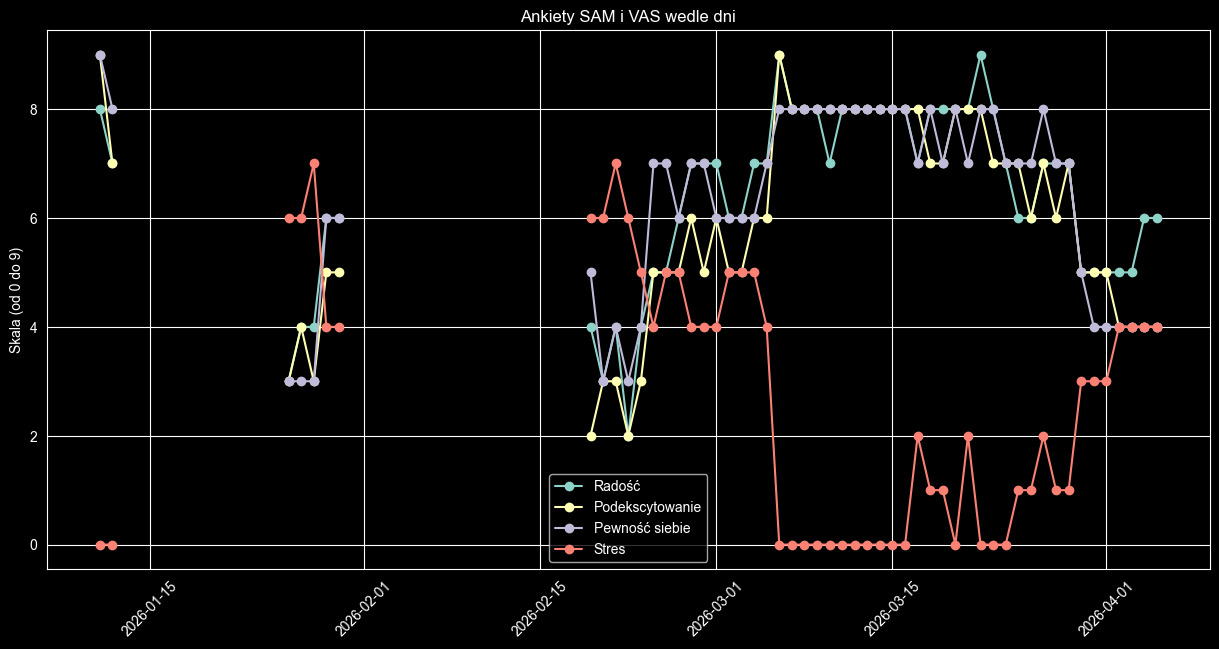

In [6]:
# Graphs
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df_full.index, df_full["Radość"], marker="o", label="Radość")
plt.plot(df_full.index, df_full["Podekscytowanie"], marker="o", label="Podekscytowanie")
plt.plot(df_full.index, df_full["Pewność siebie"], marker="o", label="Pewność siebie")
plt.plot(df_full.index, df_full["Stres"], marker="o", label="Stres")
plt.title("Ankiety SAM i VAS wedle dni")
plt.ylabel("Skala (od 0 do 9)")
plt.xticks(rotation=45)
plt.legend()
# plt.tight_layout()
plt.show()